In [3]:
!pip install requests beautifulsoup4 pandas matplotlib --quiet

In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests

from bs4 import BeautifulSoup
import re
import os
import time
import warnings

warnings.filterwarnings("ignore")

matplotlib.rcParams["font.family"] = "DejaVu Sans"

matplotlib.rcParams["axes.unicode_minus"] = False

for folder in ["data/raw", "data/processed", "visuals"]:

    os.makedirs(folder, exist_ok=True)

print("Библиотеки загружены, папки созданы.")

print(f"Pandas: {pd.__version__}, Matplotlib: {matplotlib.__version__}")

Библиотеки загружены, папки созданы.
Pandas: 2.2.2, Matplotlib: 3.10.0


In [5]:
competitors_data = [

    {

        "name": "Glitch Coffee",

        "address": "Покровский бул., 11, стр. 4",

        "yandex_url": "https://yandex.ru/maps/org/glitch_coffee/225669345210",

        "official_site": "",

        "format": "кофейня",

        "is_chain": False,

        "source": "Яндекс Карты (ручной сбор)",

    },

    {

        "name": "Jeffrey's Coffee",

        "address": "Покровский бул., 11, стр. 4",

        "yandex_url": "https://yandex.ru/maps/org/jeffreys_coffee/170195158475",

        "official_site": "https://jeffreys.ru/",

        "format": "кофейня",

        "is_chain": True,

        "source": "Яндекс Карты (ручной сбор)",

    },

    {

        "name": "2Grind",

        "address": "Покровский бул., 11, стр. 12",

        "yandex_url": "https://yandex.ru/maps/org/2grind/228978124972",

        "official_site": "",

        "format": "кофейня",

        "is_chain": False,

        "source": "Яндекс Карты (ручной сбор)",

    },

    {

        "name": "Corner Coffee",

        "address": "Покровский бул., 14/6",

        "yandex_url": "https://yandex.ru/maps/org/corner_coffee/25052458351",

        "official_site": "https://cornercoffee.ru/",

        "format": "кофейня/ростер",

        "is_chain": False,

        "source": "Яндекс Карты (ручной сбор)",

    },

    {

        "name": "Правда кофе",

        "address": "ул. Воронцово Поле, 2",

        "yandex_url": "https://yandex.ru/maps/org/pravda_kofe/189116042324",

        "official_site": "https://pravdacoffee.ru/",

        "format": "кофе to go",

        "is_chain": True,

        "source": "Яндекс Карты (ручной сбор)",

    },

    {

        "name": "Яхт-клуб Яуза",

        "address": "Подколокольный пер., 16/2с1",

        "yandex_url": "https://yandex.ru/maps/org/yakht_klub_yauza/7683219337",

        "official_site": "",

        "format": "кафе/бар",

        "is_chain": False,

        "source": "Яндекс Карты (ручной сбор)",

    },

    {

        "name": "Эль кафе",

        "address": "Казарменный пер., 6, стр. 1",

        "yandex_url": "https://yandex.ru/maps/org/el_kafe/122640642852",

        "official_site": "",

        "format": "кафе",

        "is_chain": False,

        "source": "Яндекс Карты (ручной сбор)",

    },

]

df_competitors = pd.DataFrame(competitors_data)

df_competitors.to_csv("data/raw/competitors_manual.csv", index=False, encoding="utf-8-sig")

print("Таблица конкурентов создана:")

print(df_competitors[["name", "address", "format", "is_chain"]].to_string(index=False))

Таблица конкурентов создана:
            name                      address         format  is_chain
   Glitch Coffee  Покровский бул., 11, стр. 4        кофейня     False
Jeffrey's Coffee  Покровский бул., 11, стр. 4        кофейня      True
          2Grind Покровский бул., 11, стр. 12        кофейня     False
   Corner Coffee        Покровский бул., 14/6 кофейня/ростер     False
     Правда кофе        ул. Воронцово Поле, 2     кофе to go      True
   Яхт-клуб Яуза  Подколокольный пер., 16/2с1       кафе/бар     False
        Эль кафе  Казарменный пер., 6, стр. 1           кафе     False


In [6]:
df_comp = df_competitors.copy()

df_comp["is_chain"] = df_comp["is_chain"].astype(bool)

print("Пропуски в данных:")

print(df_comp.isnull().sum())

print()

df_comp["official_site"] = df_comp["official_site"].replace("", "нет сайта")

chain_counts = df_comp["is_chain"].value_counts()

print("Сетевые vs несетевые конкуренты:")

print(f"  Сетевых:    {chain_counts.get(True, 0)}")

print(f"  Несетевых:  {chain_counts.get(False, 0)}")

print()

format_counts = df_comp["format"].value_counts()

print("Количество заведений по форматам:")

print(format_counts.to_string())

df_comp.to_csv("data/processed/competitors_processed.csv", index=False, encoding="utf-8-sig")

print("\nСохранено: data/processed/competitors_processed.csv")

Пропуски в данных:
name             0
address          0
yandex_url       0
official_site    0
format           0
is_chain         0
source           0
dtype: int64

Сетевые vs несетевые конкуренты:
  Сетевых:    2
  Несетевых:  5

Количество заведений по форматам:
format
кофейня           3
кофейня/ростер    1
кофе to go        1
кафе/бар          1
кафе              1

Сохранено: data/processed/competitors_processed.csv


In [7]:
class CoffeeSiteParser:

    """

    Парсер одного сайта кофейни.

    Принимает название и URL, делает HTTP-запрос, обрабатывает HTML через BeautifulSoup.

    """

    def __init__(self, name: str, url: str):

        self.name = name

        self.url = url

        self.soup = None

        self.success = False

    def fetch(self) -> bool:

        headers = {

            "User-Agent": (

                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "

                "AppleWebKit/537.36 (KHTML, like Gecko) "

                "Chrome/120.0.0.0 Safari/537.36"

            )

        }

        try:

            resp = requests.get(self.url, headers=headers, timeout=15)

            resp.raise_for_status()

            resp.encoding = resp.apparent_encoding or "utf-8"

            self.soup = BeautifulSoup(resp.text, "html.parser")

            self.success = True

            print(f"  [OK] {self.name}: загружено ({len(resp.text):,} символов)")

        except requests.exceptions.ConnectionError:

            print(f"  [ОШИБКА] {self.name}: нет подключения")

        except requests.exceptions.Timeout:

            print(f"  [ОШИБКА] {self.name}: таймаут")

        except Exception as e:

            print(f"  [ОШИБКА] {self.name}: {e}")

        return self.success

    def get_title(self) -> str:

        if not self.soup:

            return ""

        tag = self.soup.find("title")

        return tag.get_text(strip=True) if tag else ""

    def get_headings(self) -> dict:

        if not self.soup:

            return {}

        result = {}

        for tag in ["h1", "h2", "h3"]:

            texts = [

                el.get_text(strip=True)

                for el in self.soup.find_all(tag)

                if el.get_text(strip=True)

            ]

            if texts:

                result[tag] = texts

        return result

    def get_paragraphs(self) -> list:

        if not self.soup:

            return []

        return [

            el.get_text(strip=True)

            for el in self.soup.find_all("p")

            if el.get_text(strip=True)

        ]

    def get_links(self) -> list:

        if not self.soup:

            return []

        links = []

        for a in self.soup.find_all("a", href=True):

            href = a["href"].strip()

            text = a.get_text(strip=True)

            if href and not href.startswith("#"):

                links.append({"text": text, "href": href})

        return links

    def get_full_text(self) -> str:

        if not self.soup:

            return ""

        soup_copy = BeautifulSoup(str(self.soup), "html.parser")

        for tag in soup_copy(["script", "style", "noscript"]):

            tag.decompose()

        return " ".join(soup_copy.get_text(separator=" ").split())

    def to_dict(self) -> dict:

        headings = self.get_headings()

        return {

            "name": self.name,

            "url": self.url,

            "success": self.success,

            "title": self.get_title(),

            "h1": " | ".join(headings.get("h1", [])),

            "h2": " | ".join(headings.get("h2", [])),

            "h3": " | ".join(headings.get("h3", [])),

            "paragraphs_count": len(self.get_paragraphs()),

            "links_count": len(self.get_links()),

            "full_text_length": len(self.get_full_text()),

            "full_text_preview": self.get_full_text()[:500],

        }

sites_to_parse = [

    {"name": "Правда кофе", "url": "https://pravdacoffee.ru/"},

    {"name": "Corner Coffee", "url": "https://cornercoffee.ru/"},

    {"name": "Jeffrey's Coffee", "url": "https://jeffreys.ru/"},

]

print("Запускаем парсинг сайтов...")

all_site_data = []

all_links = []

for site in sites_to_parse:

    parser = CoffeeSiteParser(name=site["name"], url=site["url"])

    if parser.fetch():

        all_site_data.append(parser.to_dict())

        for link in parser.get_links():

            link["source_name"] = site["name"]

            link["source_url"] = site["url"]

            all_links.append(link)

    else:

        all_site_data.append({

            "name": site["name"],

            "url": site["url"],

            "success": False,

            "title": "",

            "h1": "",

            "h2": "",

            "h3": "",

            "paragraphs_count": 0,

            "links_count": 0,

            "full_text_length": 0,

            "full_text_preview": "",

        })

    time.sleep(1.5)

df_sites = pd.DataFrame(all_site_data)

df_links = pd.DataFrame(all_links) if all_links else pd.DataFrame(

    columns=["text", "href", "source_name", "source_url"]

)

df_sites.to_csv("data/raw/parsed_sites.csv", index=False, encoding="utf-8-sig")

df_links.to_csv("data/raw/parsed_links.csv", index=False, encoding="utf-8-sig")

print(f"\nРезультаты парсинга ({len(df_sites)} сайтов):")

print(df_sites[["name", "success", "title", "paragraphs_count", "links_count"]].to_string(index=False))

Запускаем парсинг сайтов...
  [OK] Правда кофе: загружено (81,513 символов)
  [OK] Corner Coffee: загружено (97,403 символов)
  [OK] Jeffrey's Coffee: загружено (105,361 символов)

Результаты парсинга (3 сайтов):
            name  success                                                           title  paragraphs_count  links_count
     Правда кофе     True                                                     Правда кофе                 0           40
   Corner Coffee     True                                         CORNER COFFEE  — CORNER                 1           10
Jeffrey's Coffee     True Сайт сети кофеен Jeffrey's Coffeeshop: работа, франшиза, аренда                 0           12


In [8]:
class PravdaMenuParser:

    """

    Специализированный парсер меню Правда кофе.

    Использует requests + BeautifulSoup + регулярные выражения.

    """

    KEY_DRINKS = [

        "американо",

        "капучино",

        "латте",

        "флэт уайт",

        "флэтуайт",

        "раф",

        "какао",

        "чай",

        "матча",

    ]

    def __init__(self, url: str = "https://pravdacoffee.ru/mainmenu/"):

        self.url = url

        self.soup = None

        self.raw_text = ""

        self.success = False

    def fetch(self) -> bool:

        headers = {

            "User-Agent": (

                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "

                "AppleWebKit/537.36 (KHTML, like Gecko) "

                "Chrome/120.0.0.0 Safari/537.36"

            )

        }

        try:

            resp = requests.get(self.url, headers=headers, timeout=15)

            resp.raise_for_status()

            resp.encoding = resp.apparent_encoding or "utf-8"

            self.soup = BeautifulSoup(resp.text, "html.parser")

            for tag in self.soup(["script", "style", "noscript"]):

                tag.decompose()

            self.raw_text = "\n".join(self.soup.get_text(separator="\n").split("\n"))

            self.success = True

            print(f"[OK] Меню загружено ({len(self.raw_text):,} символов)")

        except Exception as e:

            print(f"[ОШИБКА] Меню недоступно: {e}")

        return self.success

    def extract_prices_regex(self) -> list:

        if not self.raw_text:

            return []

        results = []

        price_pattern = re.compile(

            r"([А-ЯЁа-яёA-Za-z][А-ЯЁа-яёA-Za-z\s\-]{2,40}?)\s+"

            r"(?:(\d{2,4})\s*(?:мл|ml))?\s*"

            r"(\d{2,5})\s*(?:₽|руб|р\.?)\b",

            re.IGNORECASE,

        )

        for match in price_pattern.finditer(self.raw_text):

            name = match.group(1).strip().lower()

            volume_str = match.group(2)

            price_str = match.group(3)

            price = int(price_str)

            volume = int(volume_str) if volume_str else None

            is_key = any(kw in name for kw in self.KEY_DRINKS)

            if 80 <= price <= 700:

                results.append({

                    "drink_name": name.strip(),

                    "category": self._categorize(name),

                    "volume_ml": volume,

                    "price_rub": price,

                    "is_key_drink": is_key,

                    "source_url": self.url,

                    "validation_note": "авто" if is_key else "требует проверки",

                })

        return results

    def extract_structured(self) -> list:

        if not self.soup:

            return []

        results = []

        for cls in ["menu", "product", "item", "dish", "drink", "price", "catalog", "card"]:

            items = self.soup.find_all(class_=re.compile(cls, re.IGNORECASE))

            for item in items[:60]:

                text = item.get_text(separator=" ", strip=True)

                price_match = re.search(r"(\d{2,4})\s*(?:₽|руб|р\.?)", text)

                volume_match = re.search(r"(\d{2,4})\s*(?:мл|ml)", text, re.IGNORECASE)

                if price_match:

                    price = int(price_match.group(1))

                    volume = int(volume_match.group(1)) if volume_match else None

                    name = re.sub(r"\d+\s*(?:₽|руб|р\.?|мл|ml)", "", text).strip()[:60].lower()

                    is_key = any(kw in name for kw in self.KEY_DRINKS)

                    if 80 <= price <= 700 and len(name) > 2:

                        results.append({

                            "drink_name": name,

                            "category": self._categorize(name),

                            "volume_ml": volume,

                            "price_rub": price,

                            "is_key_drink": is_key,

                            "source_url": self.url,

                            "validation_note": "структурный парсинг",

                        })

        return results

    def _categorize(self, name: str) -> str:

        name = name.lower()

        if any(w in name for w in ["эспрессо", "американо", "лонг блэк"]):

            return "эспрессо-напитки"

        if any(w in name for w in ["капучино", "латте", "флэт", "раф", "кортадо", "макиато"]):

            return "молочные напитки"

        if any(w in name for w in ["чай", "матча"]):

            return "чай/матча"

        if any(w in name for w in ["какао", "шоколад"]):

            return "какао/шоколад"

        return "прочее"

pravda_menu_manual = [

    {"drink_name": "эспрессо", "category": "эспрессо-напитки", "volume_ml": 60, "price_rub": 130, "is_key_drink": False, "source_url": "ручной ввод", "validation_note": "ручная валидация"},

    {"drink_name": "американо", "category": "эспрессо-напитки", "volume_ml": 250, "price_rub": 175, "is_key_drink": True, "source_url": "ручной ввод", "validation_note": "ручная валидация"},

    {"drink_name": "капучино", "category": "молочные напитки", "volume_ml": 300, "price_rub": 225, "is_key_drink": True, "source_url": "ручной ввод", "validation_note": "ручная валидация"},

    {"drink_name": "латте", "category": "молочные напитки", "volume_ml": 350, "price_rub": 245, "is_key_drink": True, "source_url": "ручной ввод", "validation_note": "ручная валидация"},

    {"drink_name": "флэт уайт", "category": "молочные напитки", "volume_ml": 200, "price_rub": 245, "is_key_drink": True, "source_url": "ручной ввод", "validation_note": "ручная валидация"},

    {"drink_name": "раф", "category": "молочные напитки", "volume_ml": 300, "price_rub": 285, "is_key_drink": True, "source_url": "ручной ввод", "validation_note": "ручная валидация"},

    {"drink_name": "какао", "category": "какао/шоколад", "volume_ml": 300, "price_rub": 265, "is_key_drink": True, "source_url": "ручной ввод", "validation_note": "ручная валидация"},

    {"drink_name": "матча латте", "category": "чай/матча", "volume_ml": 300, "price_rub": 285, "is_key_drink": True, "source_url": "ручной ввод", "validation_note": "ручная валидация"},

    {"drink_name": "чай", "category": "чай/матча", "volume_ml": 400, "price_rub": 180, "is_key_drink": True, "source_url": "ручной ввод", "validation_note": "ручная валидация"},

    {"drink_name": "кортадо", "category": "молочные напитки", "volume_ml": 150, "price_rub": 225, "is_key_drink": False, "source_url": "ручной ввод", "validation_note": "ручная валидация"},

]

print("Пробуем автоматический парсинг меню Правда кофе...")

menu_parser = PravdaMenuParser()

auto_items = []

if menu_parser.fetch():

    items_regex = menu_parser.extract_prices_regex()

    items_struct = menu_parser.extract_structured()

    auto_items = items_regex + items_struct

    if auto_items:

        df_menu_auto = pd.DataFrame(auto_items).drop_duplicates(subset=["drink_name", "price_rub"])

        print(f"Автоматически извлечено: {len(df_menu_auto)} позиций")

    else:

        print("Автоматическое извлечение не дало результатов.")

        print("Используем ручные данные с валидацией.")

else:

    print("Сайт недоступен. Используем ручные данные.")

df_menu_raw = pd.DataFrame(pravda_menu_manual)

if auto_items:

    df_auto = pd.DataFrame(auto_items)

    df_menu_raw = pd.concat([df_menu_raw, df_auto], ignore_index=True).drop_duplicates(

        subset=["drink_name", "price_rub"]

    )

    print(f"Итого после объединения: {len(df_menu_raw)} позиций")

df_menu_raw.to_csv("data/raw/pravda_menu_raw.csv", index=False, encoding="utf-8-sig")

print("\nСохранено: data/raw/pravda_menu_raw.csv")

print(df_menu_raw[["drink_name", "category", "volume_ml", "price_rub", "validation_note"]].to_string(index=False))

Пробуем автоматический парсинг меню Правда кофе...
[OK] Меню загружено (4,400 символов)
Автоматически извлечено: 7 позиций
Итого после объединения: 17 позиций

Сохранено: data/raw/pravda_menu_raw.csv
                                                  drink_name         category  volume_ml  price_rub     validation_note
                                                    эспрессо эспрессо-напитки         60        130    ручная валидация
                                                   американо эспрессо-напитки        250        175    ручная валидация
                                                    капучино молочные напитки        300        225    ручная валидация
                                                       латте молочные напитки        350        245    ручная валидация
                                                   флэт уайт молочные напитки        200        245    ручная валидация
                                                         раф молочные напитки   

In [9]:
df_menu = df_menu_raw.copy()

df_menu["price_rub"] = pd.to_numeric(df_menu["price_rub"], errors="coerce")

df_menu["volume_ml"] = pd.to_numeric(df_menu["volume_ml"], errors="coerce")

df_menu["price_per_100ml"] = (df_menu["price_rub"] / df_menu["volume_ml"] * 100).round(1)

before = len(df_menu)

df_menu_clean = df_menu.dropna(subset=["price_per_100ml"])

print(f"Убрано строк без цены за 100 мл: {before - len(df_menu_clean)}")

print(f"Осталось строк: {len(df_menu_clean)}")

print("\nОбработанное меню Правда кофе:")

print(df_menu_clean[["drink_name", "category", "volume_ml", "price_rub", "price_per_100ml"]].to_string(index=False))

df_menu_clean.to_csv("data/processed/pravda_menu_processed.csv", index=False, encoding="utf-8-sig")

print("\nСохранено: data/processed/pravda_menu_processed.csv")

Убрано строк без цены за 100 мл: 0
Осталось строк: 17

Обработанное меню Правда кофе:
                                                  drink_name         category  volume_ml  price_rub  price_per_100ml
                                                    эспрессо эспрессо-напитки         60        130            216.7
                                                   американо эспрессо-напитки        250        175             70.0
                                                    капучино молочные напитки        300        225             75.0
                                                       латте молочные напитки        350        245             70.0
                                                   флэт уайт молочные напитки        200        245            122.5
                                                         раф молочные напитки        300        285             95.0
                                                       какао    какао/шоколад        300       

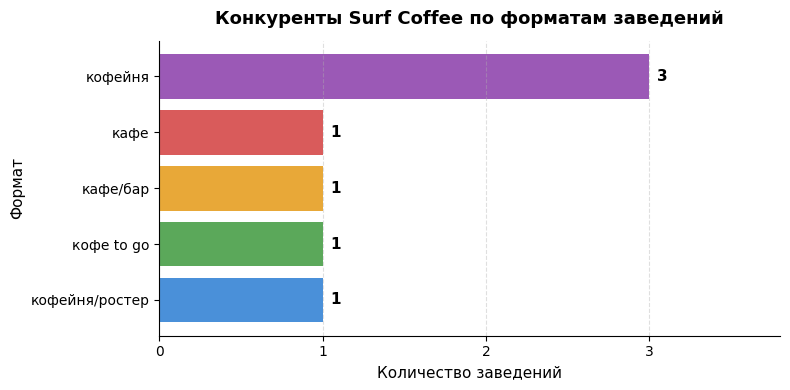

Сохранено: visuals/01_formats_barplot.png


In [10]:
format_counts = df_comp["format"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(

    format_counts.index,

    format_counts.values,

    color=["#4A90D9", "#5BA85A", "#E8A838", "#D95B5B", "#9B59B6"],

)

ax.set_title("Конкуренты Surf Coffee по форматам заведений", fontsize=13, fontweight="bold", pad=12)

ax.set_xlabel("Количество заведений", fontsize=11)

ax.set_ylabel("Формат", fontsize=11)

for bar, val in zip(bars, format_counts.values):

    ax.text(

        bar.get_width() + 0.05,

        bar.get_y() + bar.get_height() / 2,

        str(val),

        va="center",

        fontsize=11,

        fontweight="bold",

    )

ax.set_xlim(0, format_counts.max() + 0.8)

ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

plt.savefig("visuals/01_formats_barplot.png", dpi=150, bbox_inches="tight")

plt.show()

print("Сохранено: visuals/01_formats_barplot.png")

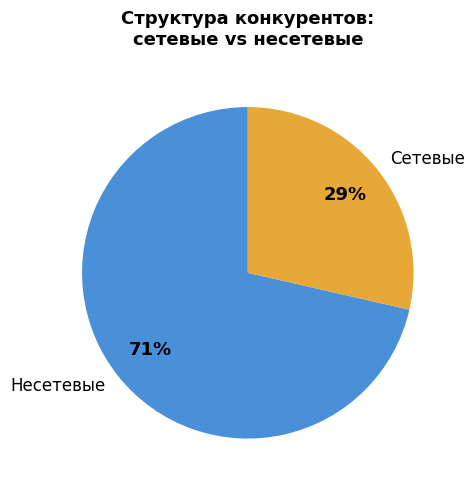

Сохранено: visuals/02_chain_vs_local_pie.png


In [11]:
chain_data = df_comp["is_chain"].value_counts()

labels = ["Несетевые" if not k else "Сетевые" for k in chain_data.index]

colors = ["#4A90D9", "#E8A838"]

fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts, autotexts = ax.pie(

    chain_data.values,

    labels=labels,

    autopct="%1.0f%%",

    colors=colors,

    startangle=90,

    pctdistance=0.75,

    textprops={"fontsize": 12},

)

for at in autotexts:

    at.set_fontsize(13)

    at.set_fontweight("bold")

ax.set_title("Структура конкурентов:\nсетевые vs несетевые", fontsize=13, fontweight="bold", pad=15)

plt.tight_layout()

plt.savefig("visuals/02_chain_vs_local_pie.png", dpi=150, bbox_inches="tight")

plt.show()

print("Сохранено: visuals/02_chain_vs_local_pie.png")

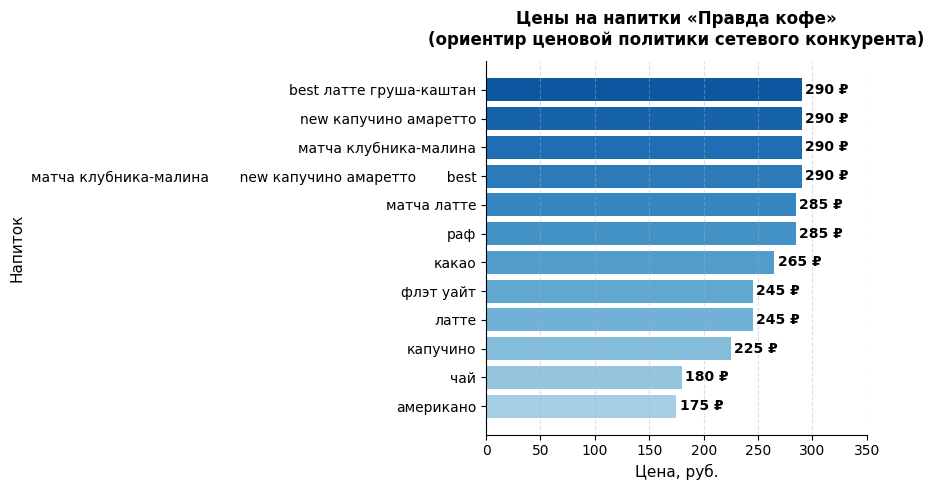

Сохранено: visuals/03_pravda_prices_barplot.png


In [12]:


df_key = df_menu_clean[df_menu_clean["is_key_drink"] == True].sort_values(

    "price_rub",

    ascending=True,

)

fig, ax = plt.subplots(figsize=(9, 5))

colors_drinks = plt.cm.Blues(np.linspace(0.35, 0.85, len(df_key)))

bars = ax.barh(df_key["drink_name"], df_key["price_rub"], color=colors_drinks)

ax.set_title(

    "Цены на напитки «Правда кофе»\n(ориентир ценовой политики сетевого конкурента)",

    fontsize=12,

    fontweight="bold",

    pad=12,

)

ax.set_xlabel("Цена, руб.", fontsize=11)

ax.set_ylabel("Напиток", fontsize=11)

for bar, val in zip(bars, df_key["price_rub"]):

    ax.text(

        bar.get_width() + 3,

        bar.get_y() + bar.get_height() / 2,

        f"{int(val)} ₽",

        va="center",

        fontsize=10,

        fontweight="bold",

    )

ax.set_xlim(0, df_key["price_rub"].max() + 60)

ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

plt.savefig("visuals/03_pravda_prices_barplot.png", dpi=150, bbox_inches="tight")

plt.show()

print("Сохранено: visuals/03_pravda_prices_barplot.png")

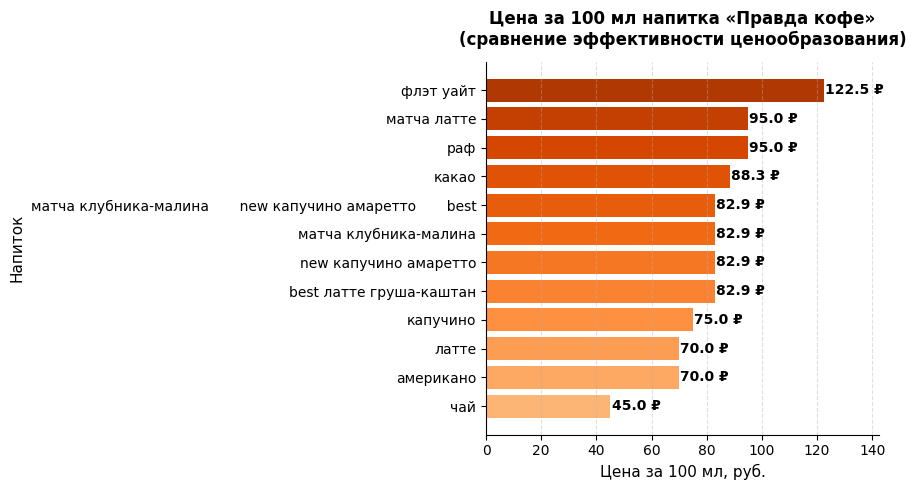

Сохранено: visuals/04_price_per_100ml.png


In [13]:
df_key_sorted = df_key.sort_values("price_per_100ml", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

colors_p100 = plt.cm.Oranges(np.linspace(0.35, 0.85, len(df_key_sorted)))

bars = ax.barh(

    df_key_sorted["drink_name"],

    df_key_sorted["price_per_100ml"],

    color=colors_p100,

)

ax.set_title(

    "Цена за 100 мл напитка «Правда кофе»\n(сравнение эффективности ценообразования)",

    fontsize=12,

    fontweight="bold",

    pad=12,

)

ax.set_xlabel("Цена за 100 мл, руб.", fontsize=11)

ax.set_ylabel("Напиток", fontsize=11)

for bar, val in zip(bars, df_key_sorted["price_per_100ml"]):

    ax.text(

        bar.get_width() + 0.5,

        bar.get_y() + bar.get_height() / 2,

        f"{val:.1f} ₽",

        va="center",

        fontsize=10,

        fontweight="bold",

    )

ax.set_xlim(0, df_key_sorted["price_per_100ml"].max() + 20)

ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

plt.savefig("visuals/04_price_per_100ml.png", dpi=150, bbox_inches="tight")

plt.show()

print("Сохранено: visuals/04_price_per_100ml.png")

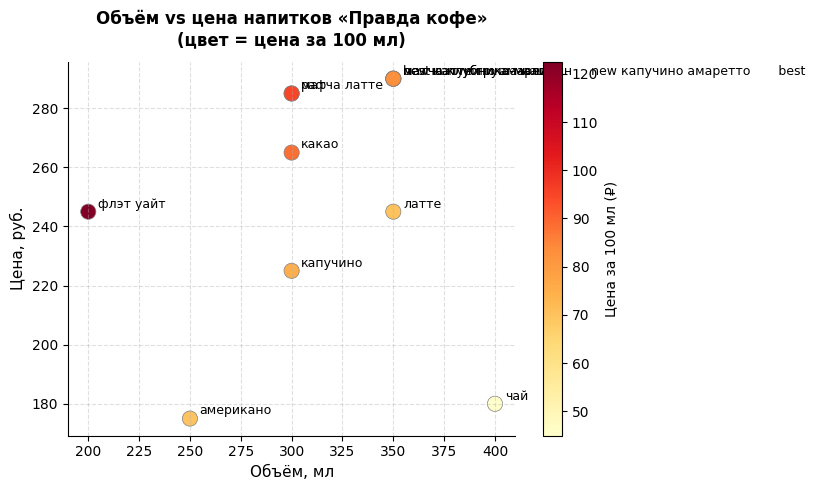

Сохранено: visuals/05_volume_vs_price_scatter.png


In [14]:


fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(

    df_key["volume_ml"],

    df_key["price_rub"],

    c=df_key["price_per_100ml"],

    cmap="YlOrRd",

    s=120,

    edgecolors="gray",

    linewidths=0.5,

)

for _, row in df_key.iterrows():

    ax.annotate(

        row["drink_name"],

        (row["volume_ml"], row["price_rub"]),

        textcoords="offset points",

        xytext=(7, 3),

        fontsize=9,

    )

cb = plt.colorbar(scatter, ax=ax)

cb.set_label("Цена за 100 мл (₽)", fontsize=10)

ax.set_title(

    "Объём vs цена напитков «Правда кофе»\n(цвет = цена за 100 мл)",

    fontsize=12,

    fontweight="bold",

    pad=12,

)

ax.set_xlabel("Объём, мл", fontsize=11)

ax.set_ylabel("Цена, руб.", fontsize=11)

ax.grid(linestyle="--", alpha=0.4)

ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

plt.savefig("visuals/05_volume_vs_price_scatter.png", dpi=150, bbox_inches="tight")

plt.show()

print("Сохранено: visuals/05_volume_vs_price_scatter.png")

In [15]:
print("""

╔══════════════════════════════════════════════════════════════════╗

║           ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ — ЧАСТЬ 1 ПРОЕКТА               ║

╚══════════════════════════════════════════════════════════════════╝

1. КОНКУРЕНТНАЯ СРЕДА

──────────────────────────────────────────────────────────────────

В ближайшем окружении Покровского бульвара работают 7 конкурентов

разных форматов: 3 классические кофейни, 1 кофейня/ростер,

1 кофе to go, 1 кафе/бар и 1 кафе.

Большинство конкурентов (5 из 7) — несетевые заведения,

что говорит о высокой доле локальных игроков с акцентом

на атмосферу и уникальный характер.

2. СЕТЕВЫЕ КОНКУРЕНТЫ

──────────────────────────────────────────────────────────────────

• Jeffrey's Coffee — сетевая кофейня с атмосферой и брендом,

  расположена прямо на Покровском бульваре (д. 11).

  Прямой конкурент по формату.

• Правда кофе — сетевой формат «кофе to go», акцент на скорость

  и доступность. Более широкая сеть, меньше атмосферы.

3. ЦЕНОВАЯ ПОЛИТИКА (на примере Правда кофе)

──────────────────────────────────────────────────────────────────

Анализ меню Правда кофе показывает:

• Диапазон цен: 130–285 руб. за напиток

• Средняя цена основных напитков: ~230 руб.

• Самый дорогой напиток: раф и матча латте (285 руб.)

• Самый дешёвый: эспрессо (130 руб.)

• Цена за 100 мл: от ~62 руб. (американо) до ~95 руб. (эспрессо)

Флэт уайт и раф имеют наибольшую цену за 100 мл среди молочных

напитков — это говорит о маржинальности малых объёмов.

4. ПОЗИЦИЯ SURF COFFEE

──────────────────────────────────────────────────────────────────

Surf Coffee может занять нишу, которая частично свободна:

• кофейня с узнаваемым федеральным брендом (как Jeffrey's),

• ориентированная на студентов и сотрудников ВШЭ,

• с пространством для учёбы/работы,

• с едой (выпечка, десерты, лёгкие блюда),

• с ценами, сопоставимыми с рынком (~180–300 руб.),

• акцент на атмосферу и «свой» характер места.

5. ЧТО ОСТАЛОСЬ ВЫЯСНИТЬ (часть 2)

──────────────────────────────────────────────────────────────────

• Насколько студенты и сотрудники ВШЭ готовы платить за кофе?

• Как часто они покупают кофе рядом с кампусом?

• Какие форматы и атмосфера им важны?

• Финансовая модель: аренда, издержки, точка безубыточности.

""")



╔══════════════════════════════════════════════════════════════════╗

║           ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ — ЧАСТЬ 1 ПРОЕКТА               ║

╚══════════════════════════════════════════════════════════════════╝

1. КОНКУРЕНТНАЯ СРЕДА

──────────────────────────────────────────────────────────────────

В ближайшем окружении Покровского бульвара работают 7 конкурентов

разных форматов: 3 классические кофейни, 1 кофейня/ростер,

1 кофе to go, 1 кафе/бар и 1 кафе.

Большинство конкурентов (5 из 7) — несетевые заведения,

что говорит о высокой доле локальных игроков с акцентом

на атмосферу и уникальный характер.

2. СЕТЕВЫЕ КОНКУРЕНТЫ

──────────────────────────────────────────────────────────────────

• Jeffrey's Coffee — сетевая кофейня с атмосферой и брендом,

  расположена прямо на Покровском бульваре (д. 11).

  Прямой конкурент по формату.

• Правда кофе — сетевой формат «кофе to go», акцент на скорость

  и доступность. Более широкая сеть, меньше атмосферы.

3. ЦЕНОВАЯ ПОЛИТИКА (на пр

In [16]:
print("Файлы проекта:")

for root, dirs, files in os.walk("."):

    dirs[:] = [

        d for d in dirs

        if d not in [".git", "__pycache__", ".ipynb_checkpoints", "sample_data"]

    ]

    level = root.replace(".", "").count(os.sep)

    indent = "  " * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = "  " * (level + 1)

    for f in files:

        fpath = os.path.join(root, f)

        size_kb = os.path.getsize(fpath) / 1024

        print(f"{subindent}{f}  ({size_kb:.1f} KB)")

Файлы проекта:
./
  parsed_links.csv  (7.2 KB)
  parsed_sites.csv  (2.9 KB)
  .config/
    default_configs.db  (12.0 KB)
    .last_update_check.json  (0.1 KB)
    .last_survey_prompt.yaml  (0.0 KB)
    hidden_gcloud_config_universe_descriptor_data_cache_configs.db  (12.0 KB)
    active_config  (0.0 KB)
    .last_opt_in_prompt.yaml  (0.0 KB)
    gce  (0.0 KB)
    config_sentinel  (0.0 KB)
    configurations/
      config_default  (0.1 KB)
    logs/
      2026.05.12/
        13.29.40.400999.log  (0.7 KB)
        13.29.25.418951.log  (12.4 KB)
        13.29.27.205677.log  (0.5 KB)
        13.29.12.483949.log  (0.5 KB)
        13.29.39.608616.log  (0.7 KB)
        13.28.53.384927.log  (49.6 KB)
  visuals/
    04_price_per_100ml.png  (93.9 KB)
    01_formats_barplot.png  (42.4 KB)
    02_chain_vs_local_pie.png  (35.2 KB)
    05_volume_vs_price_scatter.png  (83.4 KB)
    03_pravda_prices_barplot.png  (86.6 KB)
  data/
    raw/
      competitors_manual.csv  (1.4 KB)
      parsed_links.csv  (6

In [17]:
import shutil

shutil.make_archive("surf_coffee_project_part1", "zip", ".")

from google.colab import files
files.download("surf_coffee_project_part1.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>